In [2]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from sklearn.cluster import DBSCAN, OPTICS
import pandas as pd
from scipy.ndimage import sobel, uniform_filter1d
import scipy
import xarray as xr
import cv2 as cv

plt.rcParams['image.origin'] = 'lower'
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['figure.figsize'] = (20, 5)

/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_51637/3541732388.py:7: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
dir = '/Users/mleclair/phd/code/dunex/data/argus'
file = 'ArgusFF_20211013T170100Z_RectifiedVideo.avi'
os.path.join(dir, file) 

'/Users/mleclair/phd/code/dunex/data/argus/ArgusFF_20211013T170100Z_RectifiedVideo.avi'

In [4]:
cap = cv2.VideoCapture(os.path.join(dir, file))
N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f'{np.zeros((N, W), dtype=np.uint8).nbytes/1000/1000}mb per timestack')

# NOTE: We're downsampling in along-shore to 10m
skip = 1
timestack = np.zeros((N, H//skip, W))

for i in tqdm(range(N)):
    _, frame = cap.read()
    timestack[i] = frame[::skip, :, 0]

cap.release()
cv2.destroyAllWindows()

1.92mb per timestack


  0%|          | 0/3840 [00:00<?, ?it/s]

100%|██████████| 3840/3840 [00:05<00:00, 666.64it/s]


In [6]:
diff = timestack[1:] - timestack[:-1]

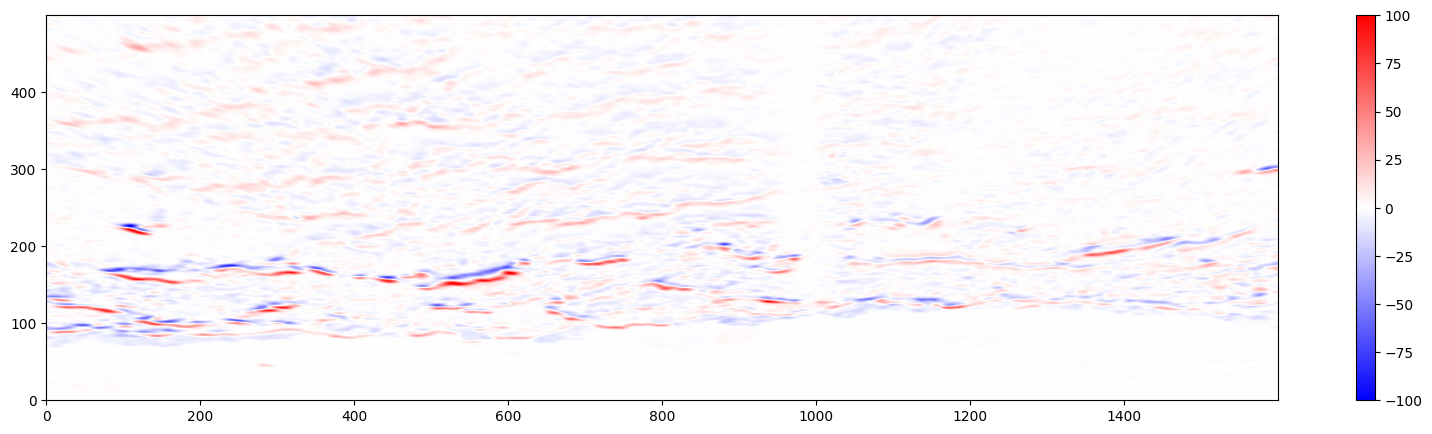

In [13]:
plt.imshow(scipy.ndimage.gaussian_filter(diff[0].T, (1, 5)), cmap='bwr', vmin=-100, vmax=100)
plt.colorbar()
# plt.xlim(700, 1300)

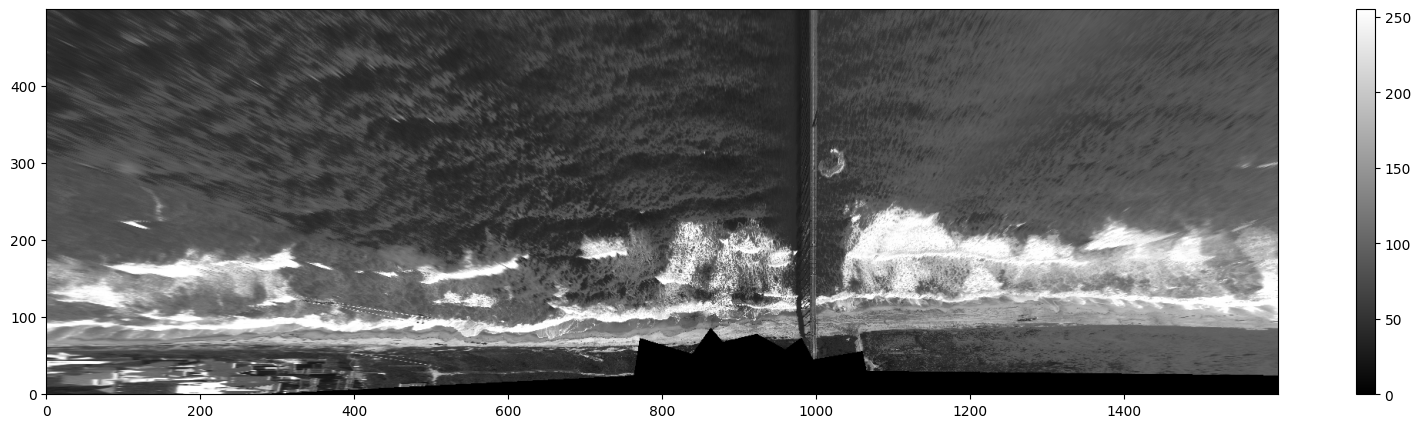

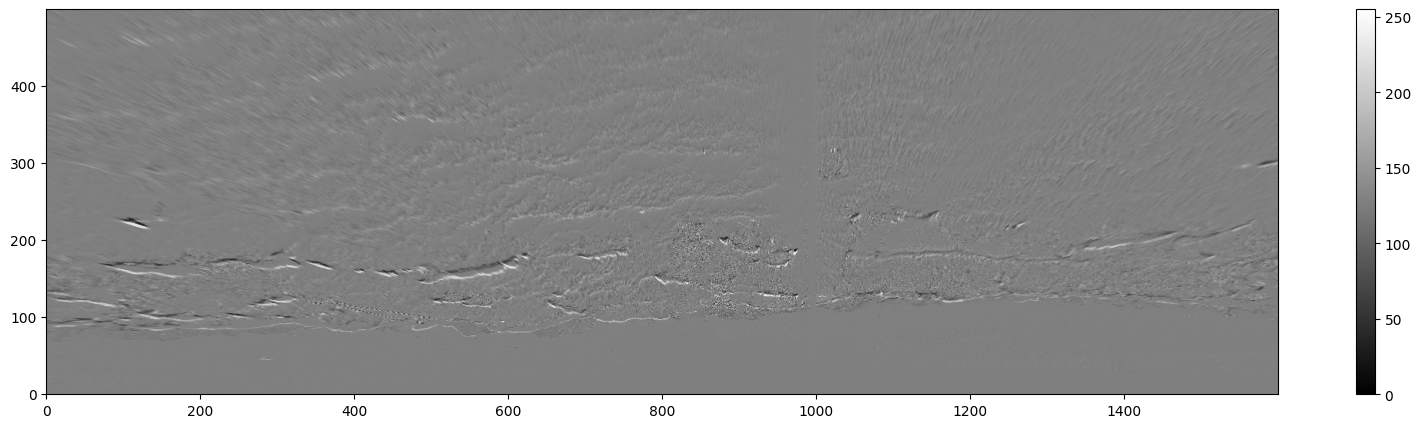

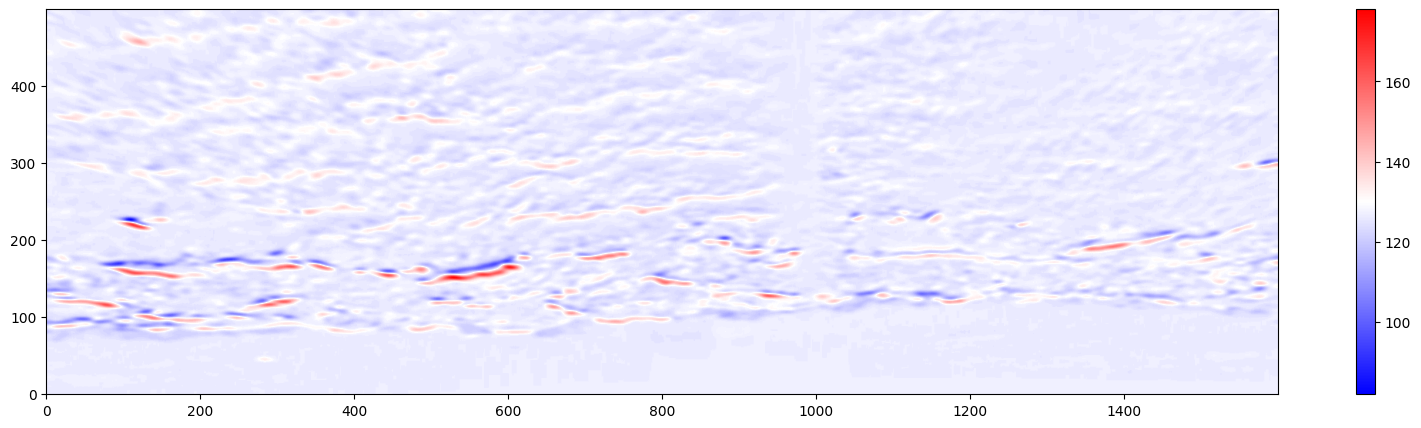

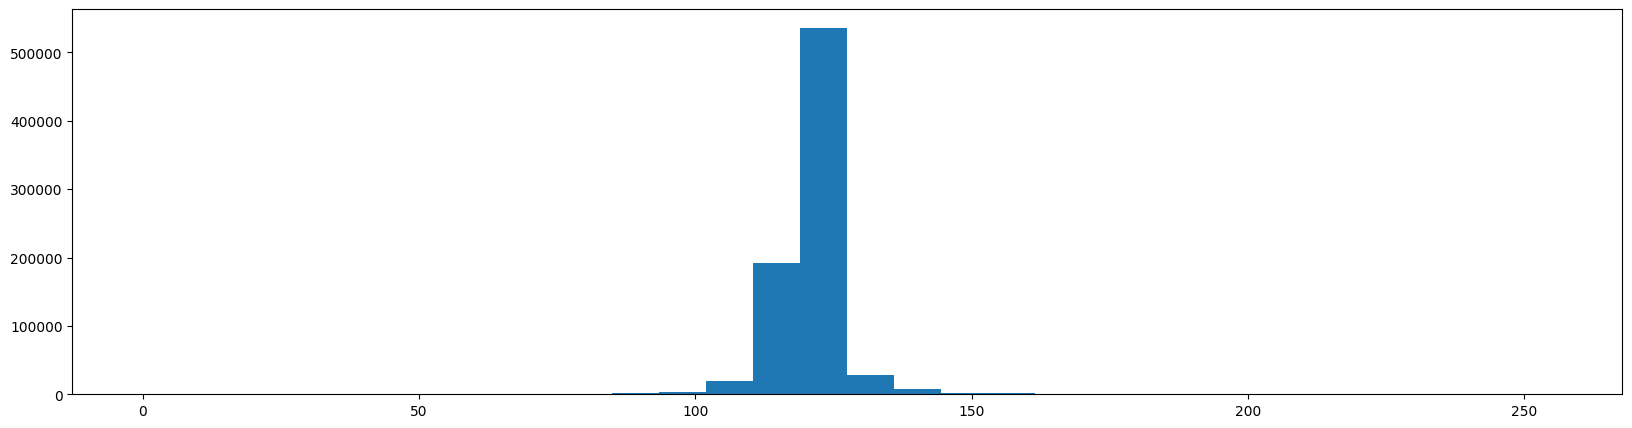

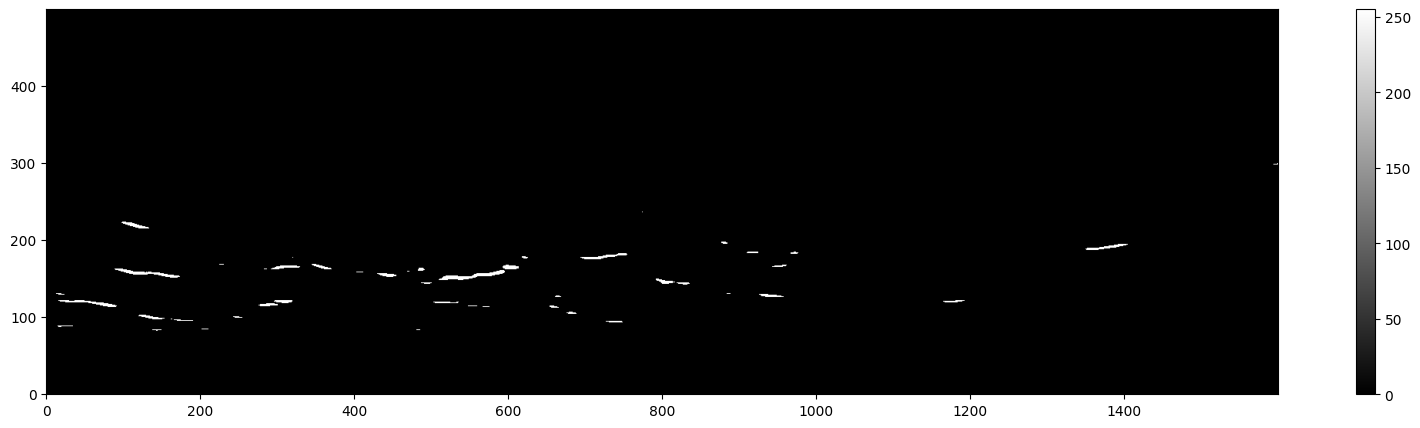

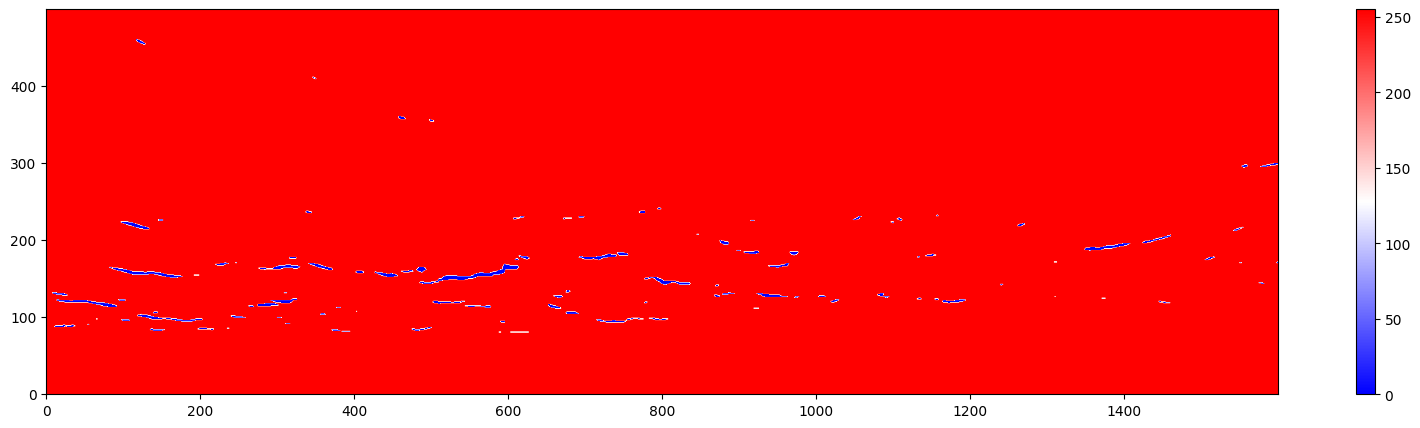

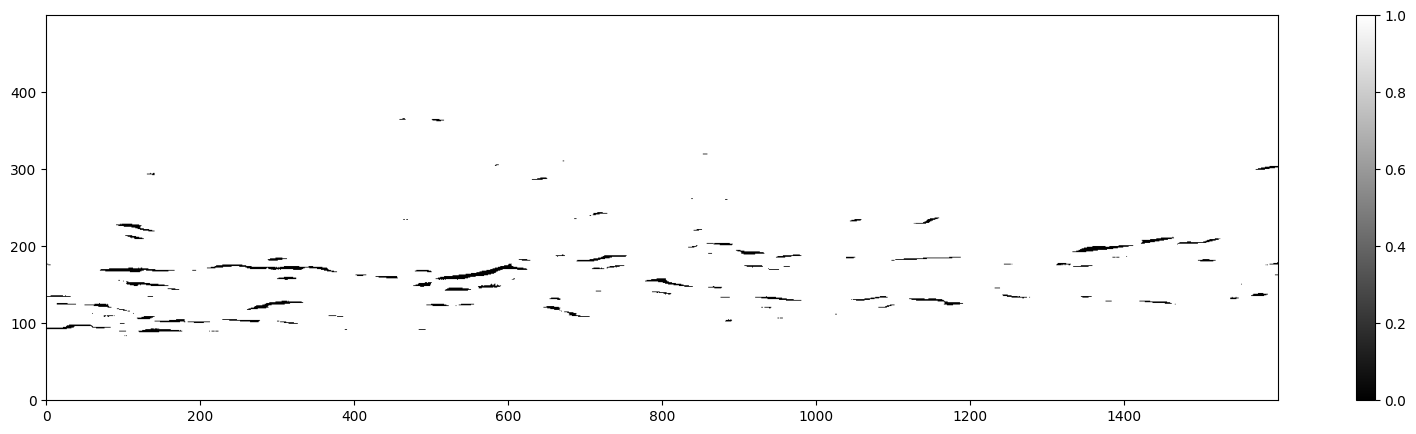

In [53]:
import scipy
def normalize(x, scale=255):
    x = (x - x.min())
    return (x/x.max() * scale).astype(np.uint8)
img = normalize(diff[0])

plt.imshow(timestack[1].T)
plt.colorbar()
plt.figure()
plt.imshow(img.T)
plt.colorbar()
plt.figure()
plt.imshow(
    # ~cv.threshold(
        scipy.ndimage.gaussian_filter(img, (5, 2)).T,
        # 0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)[1]
        cmap='bwr',
)
plt.colorbar()
plt.figure()
plt.hist(normalize(scipy.ndimage.gaussian_filter(img, (5, 1))).flatten(), bins=30)
plt.figure()
plt.imshow(
    cv.threshold(
        scipy.ndimage.gaussian_filter(img, (5, 1)).T,
        150,255,cv.THRESH_BINARY)[1],
)
plt.colorbar()

plt.figure()
plt.imshow(
    ~cv.threshold(
        normalize(cv.GaussianBlur(img,(3,15),0).T),
        150,255,cv.THRESH_BINARY)[1],
        # 0,255,cv.THRESH_BINARY+cv.THRESH_OTSU)[1],
    cmap='bwr',
)        

plt.colorbar()
plt.figure()
plt.imshow(
    scipy.ndimage.binary_dilation(cv.adaptiveThreshold(
        normalize(scipy.ndimage.gaussian_filter(img, (7, 1))),
        255,
        cv.ADAPTIVE_THRESH_MEAN_C,
        cv.THRESH_BINARY,
        21,
        14), iterations=1).T
)
plt.colorbar()


In [50]:
breakers = np.zeros_like(diff)
for i in tqdm(range(diff.shape[0])):
    img = diff[i]
    breakers[i] = cv.threshold(
        normalize(scipy.ndimage.gaussian_filter(img, (5, 1))),
        145,255,cv.THRESH_BINARY)[1]


 14%|█▍        | 538/3839 [00:07<00:43, 75.10it/s]/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_51637/3665743524.py:4: RuntimeWarning: invalid value encountered in divide
  return (x/x.max() * scale).astype(np.uint8)
/var/folders/xv/4vxt441n3tz_yllzvqvzmsgw0000gr/T/ipykernel_51637/3665743524.py:4: RuntimeWarning: invalid value encountered in cast
  return (x/x.max() * scale).astype(np.uint8)
100%|██████████| 3839/3839 [00:51<00:00, 75.12it/s]


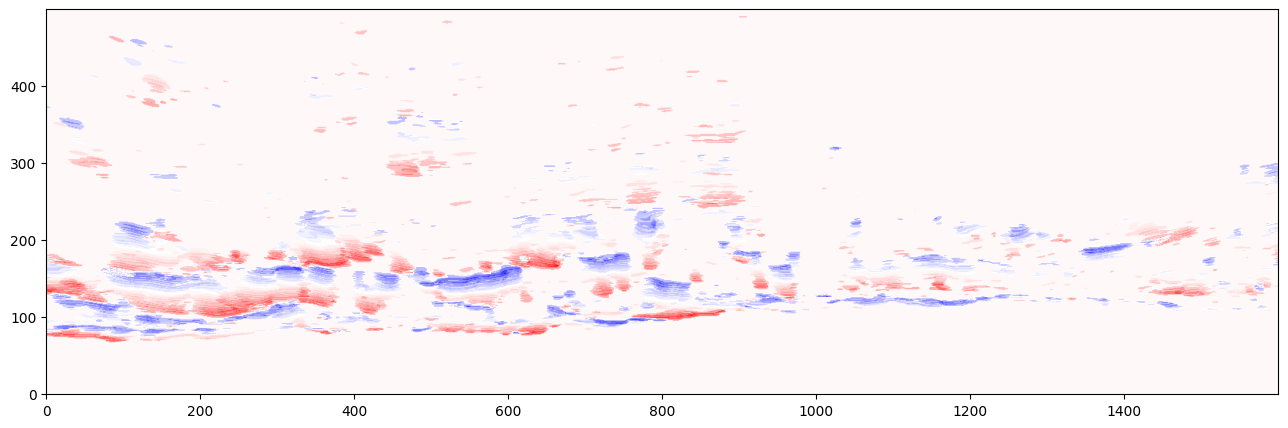

In [60]:
n = 10
i = 10

plt.imshow(((breakers[i-n:i] *     np.linspace(-n, -1, n)[:, np.newaxis, np.newaxis]).sum(0) +
            (breakers[i+1:i+n+1] * np.linspace(1, n, n)[:, np.newaxis, np.newaxis]).sum(0)).T,
           cmap='bwr')

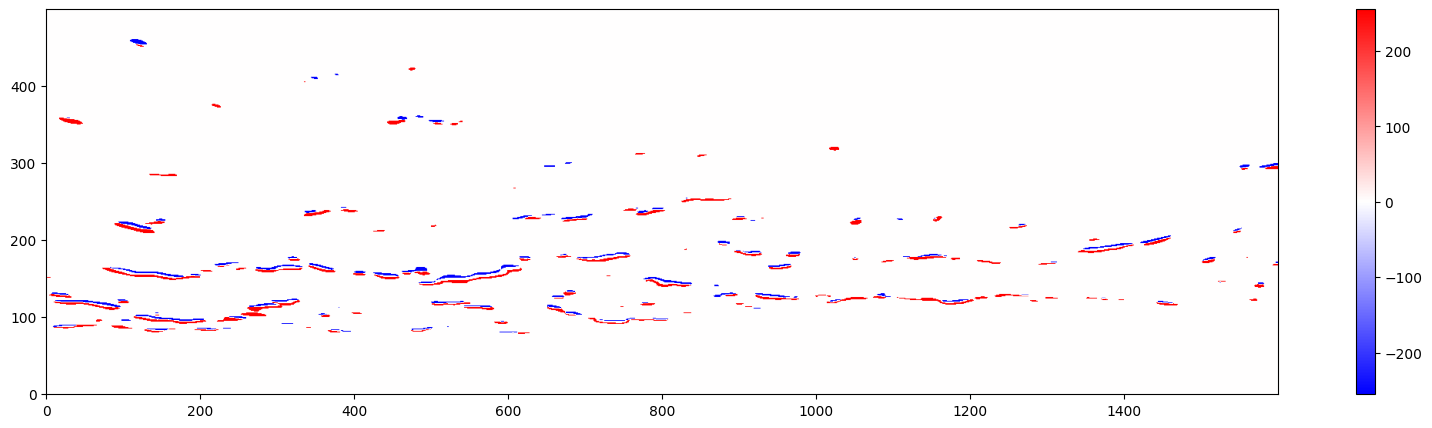

In [52]:
plt.imshow((breakers[1] - breakers[0]).T, cmap='bwr')
plt.colorbar()